In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import sweetviz as sv
import seaborn as sns

pd.set_option('display.max_colwidth', None)

## Data Load

In [2]:
data_path = '../../data/emotion/origin/emotion-emotion_69k.csv'
df = pd.read_csv(data_path)

In [3]:
df = df[['Situation', 'emotion', 'empathetic_dialogues', 'labels']]
df.head()

,Situation,emotion,empathetic_dialogues,labels
0,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",sentimental,"Customer :I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.\nAgent :","Was this a friend you were in love with, or just a best friend?"
1,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",sentimental,Customer :This was a best friend. I miss her.\nAgent :,Where has she gone?
2,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",sentimental,Customer :We no longer talk.\nAgent :,Oh was this something that happened because of an argument?
3,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",sentimental,"Customer :Was this a friend you were in love with, or just a best friend?\nAgent :",This was a best friend. I miss her.
4,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",sentimental,Customer :Where has she gone?\nAgent :,We no longer talk.


                                             |          | [  0%]   00:00 -> (? left)


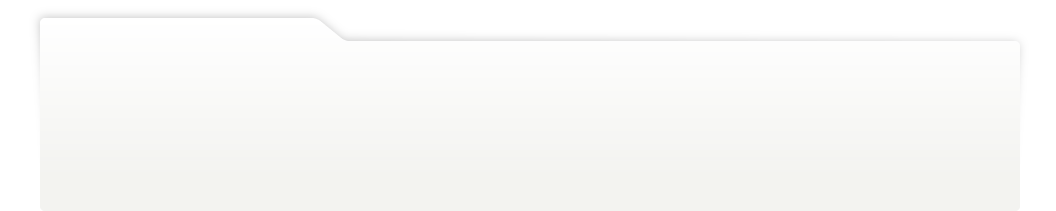
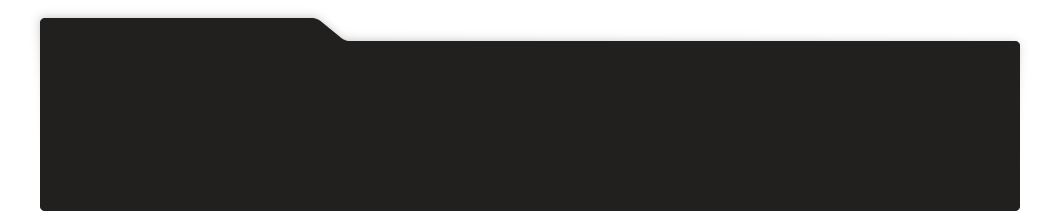
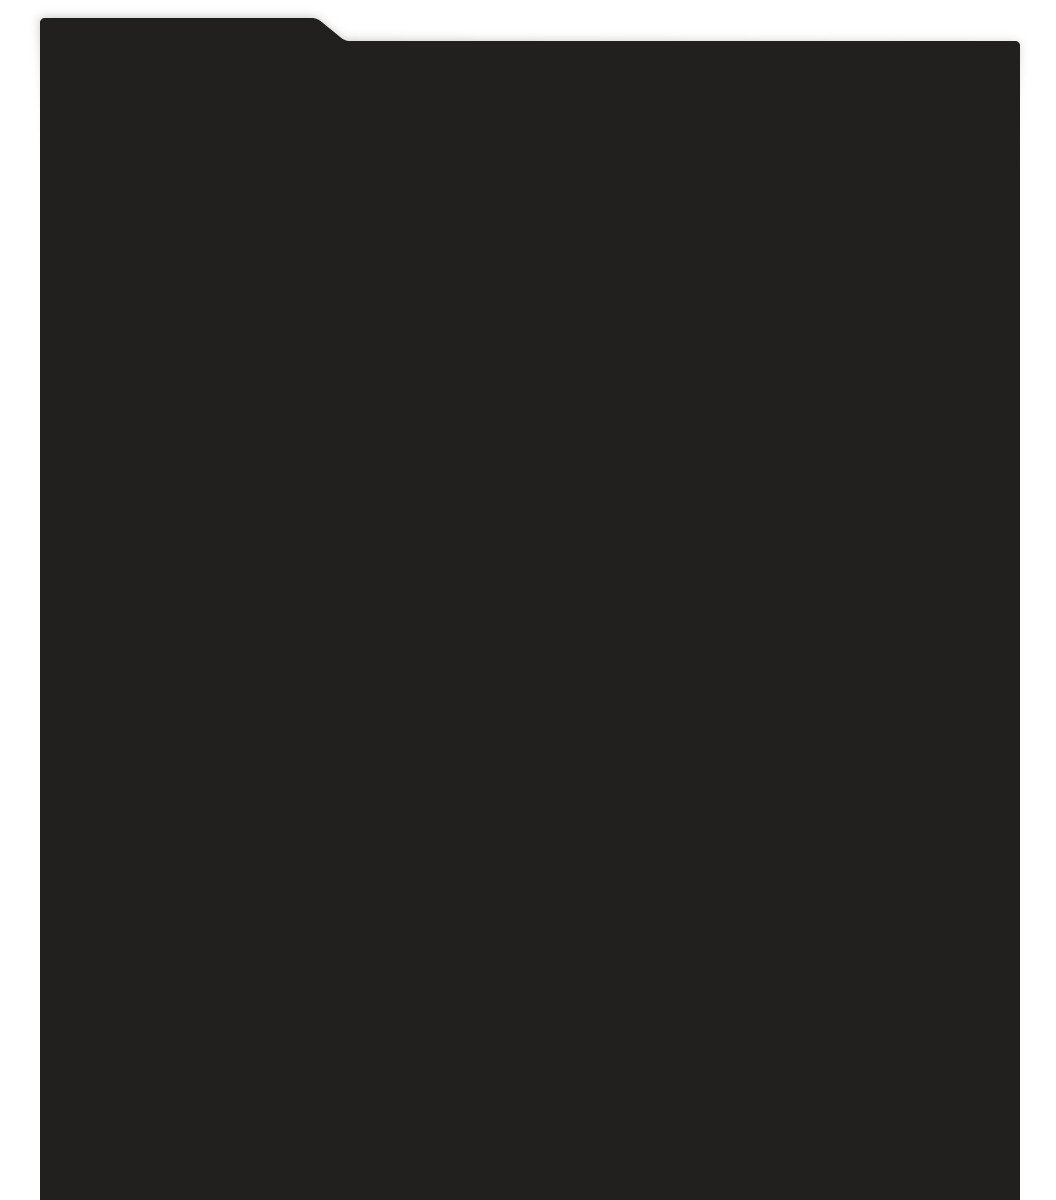
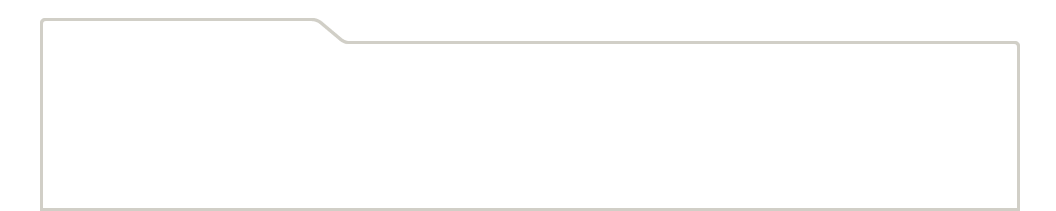
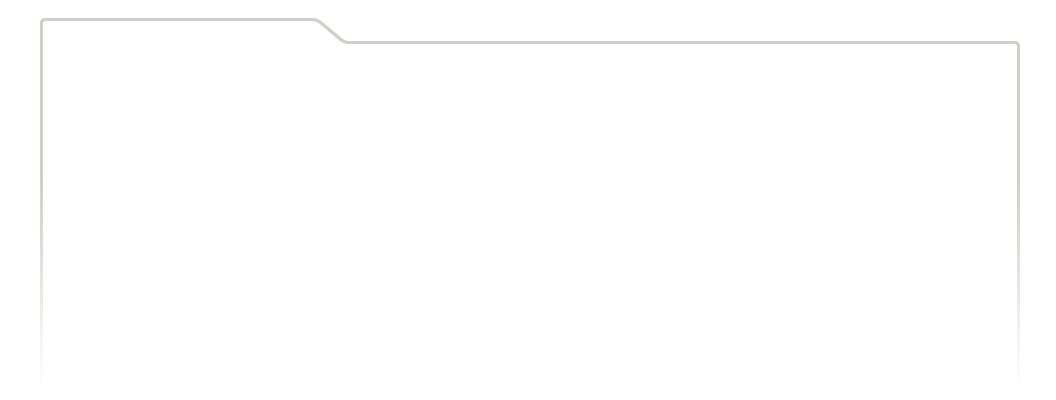
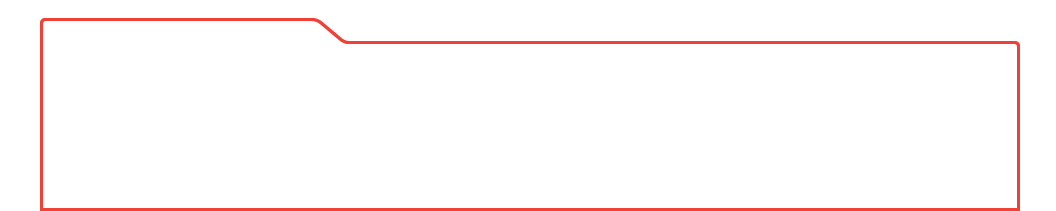
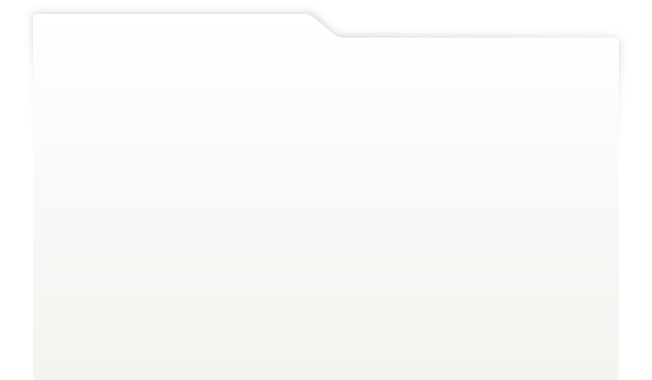
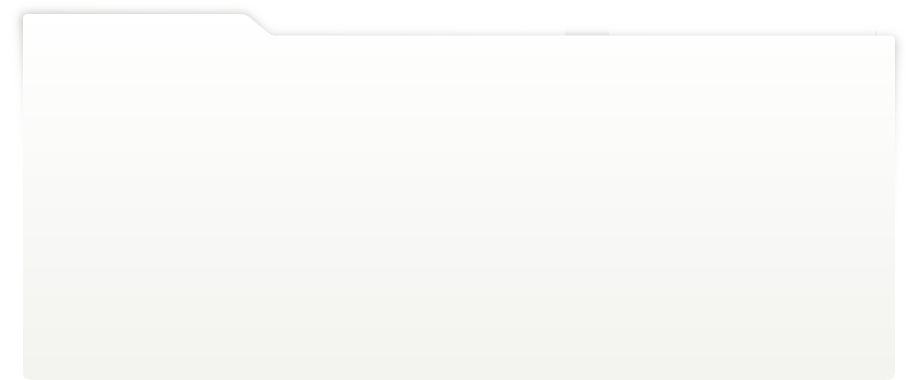
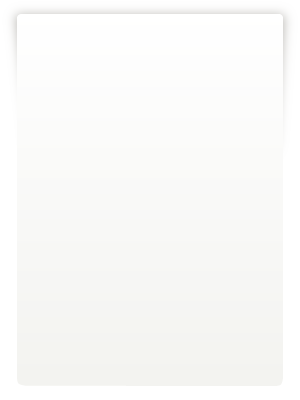
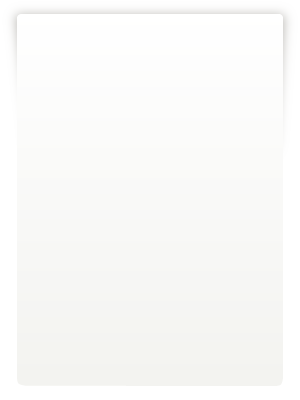
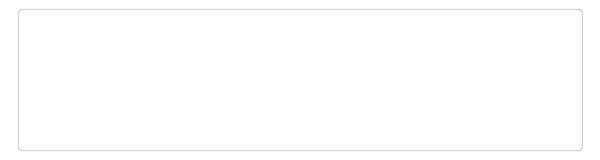
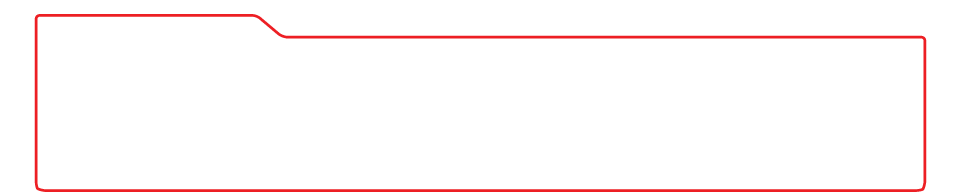
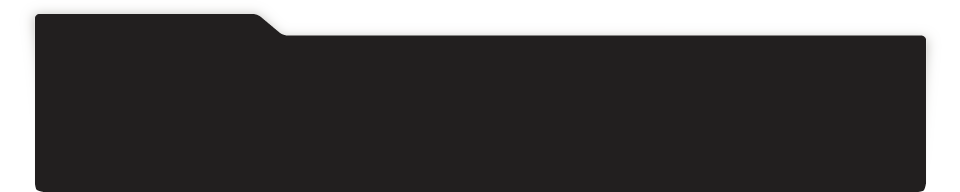
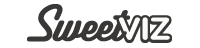
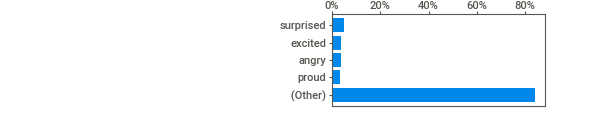
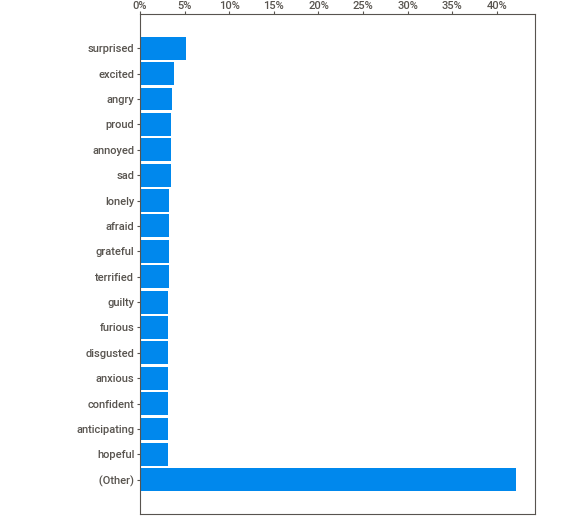
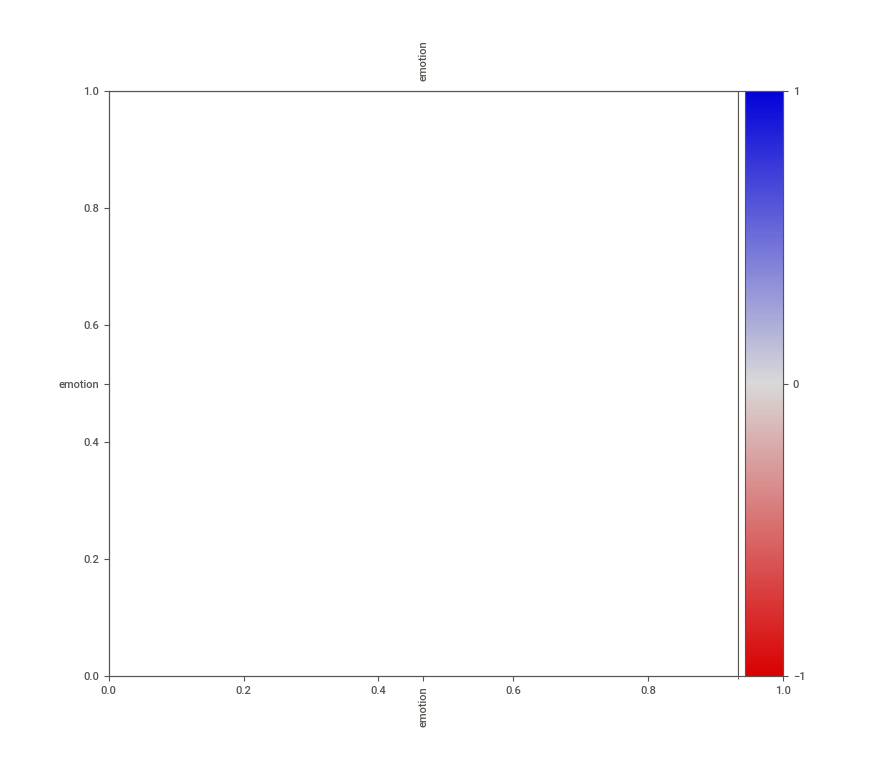
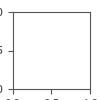

In [4]:
report = sv.analyze(df)
report.show_notebook()

## Data Preprocessing

### 1. Reducing Categories of emotion from 30 to 8

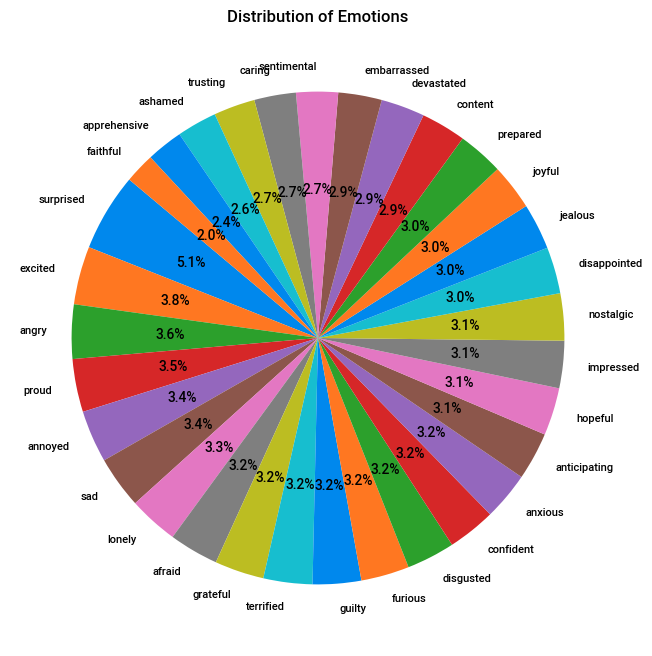

In [5]:
emotion_counts = df['emotion'].value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(emotion_counts, labels=emotion_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Emotions')
plt.show()

In [6]:
# Mapping emotions to their groups
emotion_mapping = {
    'surprised': 'excited',
    'joyful': 'excited',
    'terrified': 'afraid',
    'anxious': 'afraid',
    'apprehensive': 'afraid',
    'disgusted': 'disgusted',
    'embarrassed': 'disgusted',
    'guilty': 'disgusted',
    'ashamed': 'disgusted',
    'angry': 'annoyed',
    'annoyed': 'annoyed',
    'jealous': 'annoyed',
    'furious': 'annoyed',
    'faithful': 'grateful',
    'trusting': 'grateful',
    'grateful': 'grateful',
    'caring': 'grateful',
    'hopeful': 'grateful',
    'sad': 'disappointed',
    'disappointed': 'disappointed',
    'devastated': 'disappointed',
    'lonely': 'disappointed',
    'nostalgic': 'disappointed',
    'sentimental': 'disappointed',
    'proud': 'impressed',
    'impressed': 'impressed',
    'content': 'impressed',
    'anticipating': 'prepared',
    'prepared': 'prepared',
    'confident': 'prepared'
}
emotions = {}
df['grouped_emotion'] = df['emotion'].map(emotion_mapping)

In [7]:
group_counts = df['grouped_emotion'].value_counts()
print(group_counts)
print("total counts:", df['grouped_emotion'].shape[0])
df.dropna(inplace=True)

grouped_emotion
disappointed    11913
grateful         8913
annoyed          8509
disgusted        7635
impressed        6154
prepared         6000
afraid           5660
excited          5251
Name: count, dtype: int64
total counts: 64598


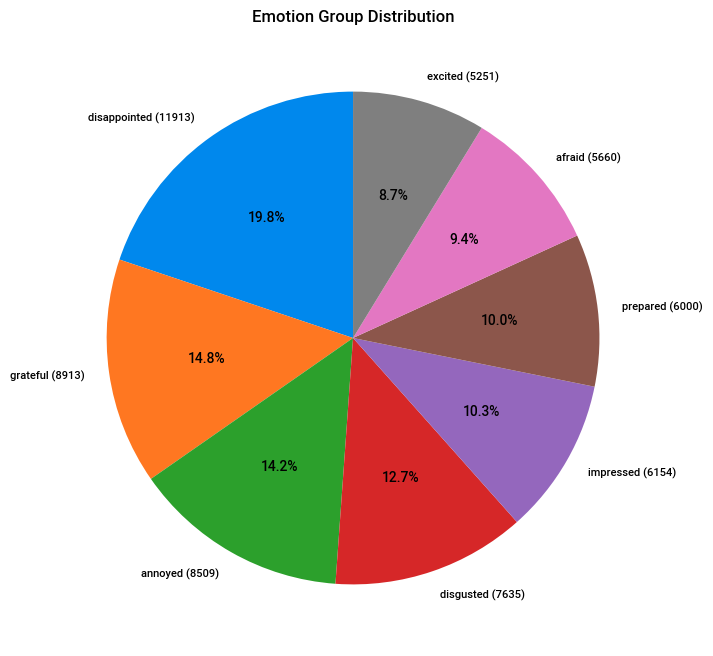

In [8]:
plt.figure(figsize=(8, 8))
group_counts.plot(kind='pie',labels=[f'{label} ({count})' for label, count in zip(group_counts.index, group_counts)], autopct='%1.1f%%', startangle=90)
plt.title('Emotion Group Distribution')
plt.ylabel('')  # Hide the y-axis label (unnecessary for pie chart)
plt.show()

In [9]:
df = df.drop(columns=['emotion'])
df = df.rename(columns={'grouped_emotion': 'emotion'})

### 2. Removing Prefix and Suffix from empathetic_dialogues

In [10]:
df['empathetic_dialogues'] = df['empathetic_dialogues'].str.replace(r'^Customer :|Agent :$', '', regex=True).str.strip()
df.dropna(inplace=True)
df.head()

,Situation,empathetic_dialogues,labels,emotion
0,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.","Was this a friend you were in love with, or just a best friend?",disappointed
1,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",This was a best friend. I miss her.,Where has she gone?,disappointed
2,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",We no longer talk.,Oh was this something that happened because of an argument?,disappointed
3,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","Was this a friend you were in love with, or just a best friend?",This was a best friend. I miss her.,disappointed
4,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",Where has she gone?,We no longer talk.,disappointed


### 3. Removing Improper Elements and Handling Missing Values

In [11]:
for column in df.columns:
    min_length_row = df[column].str.len().idxmin() 
    print(f"Column '{column}' - Shortest entry: '{df[column][min_length_row]}'")

Column 'Situation' - Shortest entry: '1'
Column 'empathetic_dialogues' - Shortest entry: '3'
Column 'labels' - Shortest entry: '4'
Column 'emotion' - Shortest entry: 'afraid'


⭡ there are non proper elements like only number, so let's filter them out if they are less than 3 characters.

In [12]:
columns_to_check = ['Situation','grouped_emotion', 'empathetic_dialogues', 'labels']
mask = ~df.apply(lambda x: x.str.len() < 3).any(axis=1)
df = df[mask]

for column in df.columns:
    min_length_row = df[column].str.len().idxmin() 
    print(f"Column '{column}' - Shortest entry: '{df[column][min_length_row]}'")

Column 'Situation' - Shortest entry: 'Lies'
Column 'empathetic_dialogues' - Shortest entry: 'Yes'
Column 'labels' - Shortest entry: 'Yes'
Column 'emotion' - Shortest entry: 'afraid'


In [13]:
df.head()

,Situation,empathetic_dialogues,labels,emotion
0,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.","Was this a friend you were in love with, or just a best friend?",disappointed
1,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",This was a best friend. I miss her.,Where has she gone?,disappointed
2,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",We no longer talk.,Oh was this something that happened because of an argument?,disappointed
3,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","Was this a friend you were in love with, or just a best friend?",This was a best friend. I miss her.,disappointed
4,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",Where has she gone?,We no longer talk.,disappointed


### 4&5. Repeated Data Handling & Stopword Removal
**Considered but not actually used for model training!**

#### Repeated Conversation Handling

In [13]:
index_to_delete = []

for index, row in df.iterrows():
    if row['empathetic_dialogues'] in df['labels'][:index].values:
        index_to_delete.append(index)

duplicates = df.loc[index_to_delete]
duplicates_sorted = duplicates.sort_index()
duplicates.head()

,Situation,empathetic_dialogues,labels,emotion
3,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","Was this a friend you were in love with, or just a best friend?",This was a best friend. I miss her.,disappointed
4,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",Where has she gone?,We no longer talk.,disappointed
11,I showed a guy how to run a good bead in welding class and he caught on quick.,"Im good, trying to understand how someone can feel like hitting a blank wall when they see the darkness",it's quite strange that you didnt imagine it,impressed
12,I showed a guy how to run a good bead in welding class and he caught on quick.,doing good.. how about you,"Im good, trying to understand how someone can feel like hitting a blank wall when they see the darkness",impressed
13,I showed a guy how to run a good bead in welding class and he caught on quick.,it's quite strange that you didnt imagine it,"i dont imagine feeling a lot, maybe your on to something",impressed


In [59]:
len(duplicates)

40779

In [ ]:
# final_df = df[~df.isin(duplicates).all(axis=1)].reset_index(drop=True)
# final_df

#### Stop Words Processing

In [14]:
import nltk
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/jihyunryu/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/jihyunryu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jihyunryu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [15]:
def preprocess_text(text):
    text = re.sub(r'[^\w\s]', '', text)  
    text = text.lower() 
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stopwords.words('english')]
    return ' '.join(tokens)

def preprocess(text):
    return text.split()

final_df = df.copy()
final_df['cleaned_input'] = df['empathetic_dialogues'].apply(preprocess_text)
final_df['cleaned_output'] = df['labels'].apply(preprocess_text)

final_df.head()

,Situation,empathetic_dialogues,labels,emotion,cleaned_input,cleaned_output
0,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.","Was this a friend you were in love with, or just a best friend?",disappointed,remember going see fireworks best friend first time ever spent time alone together although lot people felt like people world,friend love best friend
1,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",This was a best friend. I miss her.,Where has she gone?,disappointed,best friend miss,gone
2,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",We no longer talk.,Oh was this something that happened because of an argument?,disappointed,longer talk,oh something happened argument
3,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.","Was this a friend you were in love with, or just a best friend?",This was a best friend. I miss her.,disappointed,friend love best friend,best friend miss
4,"I remember going to the fireworks with my best friend. There was a lot of people, but it only felt like us in the world.",Where has she gone?,We no longer talk.,disappointed,gone,longer talk


## Exploratory Data Analysis (EDA)

In [16]:
df = df.reset_index(drop=True)
df.tail()

,Situation,empathetic_dialogues,labels,emotion
59830,I found some pictures of my grandma in the attic last night,Did you find anything great?,Yeah I found some old pictures of when us kids used to go to my grandma's house for xmas,disappointed
59831,I found some pictures of my grandma in the attic last night,What a wonderful memory.,Yeah reminds me of the good old days. I miss my grandma. She passed away about 15 years ago.,disappointed
59832,I woke up this morning to my wife telling me she was pregnant!,I woke up this morning to my wife telling me she's pregnant!,Oh hey that's awesome! That is awesome right?,excited
59833,I woke up this morning to my wife telling me she was pregnant!,"It is soooo awesome. We have been wanting a baby for so long. I can't wait, but I was shocked out of a dead sleep!",That is awesome!!!! Congratulations!,excited
59834,I woke up this morning to my wife telling me she was pregnant!,Oh hey that's awesome! That is awesome right?,"It is soooo awesome. We have been wanting a baby for so long. I can't wait, but I was shocked out of a dead sleep!",excited


                                             |          | [  0%]   00:00 -> (? left)


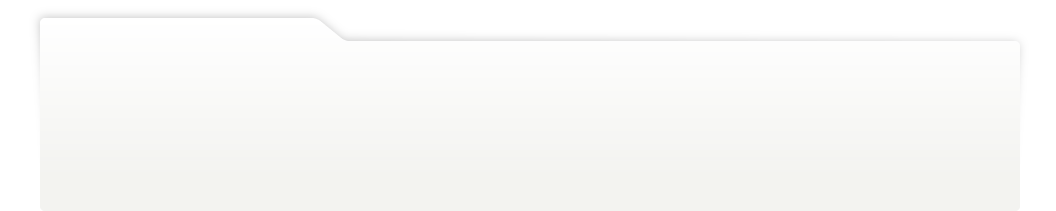
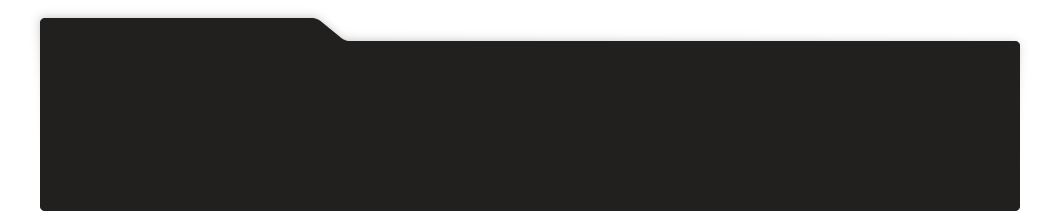
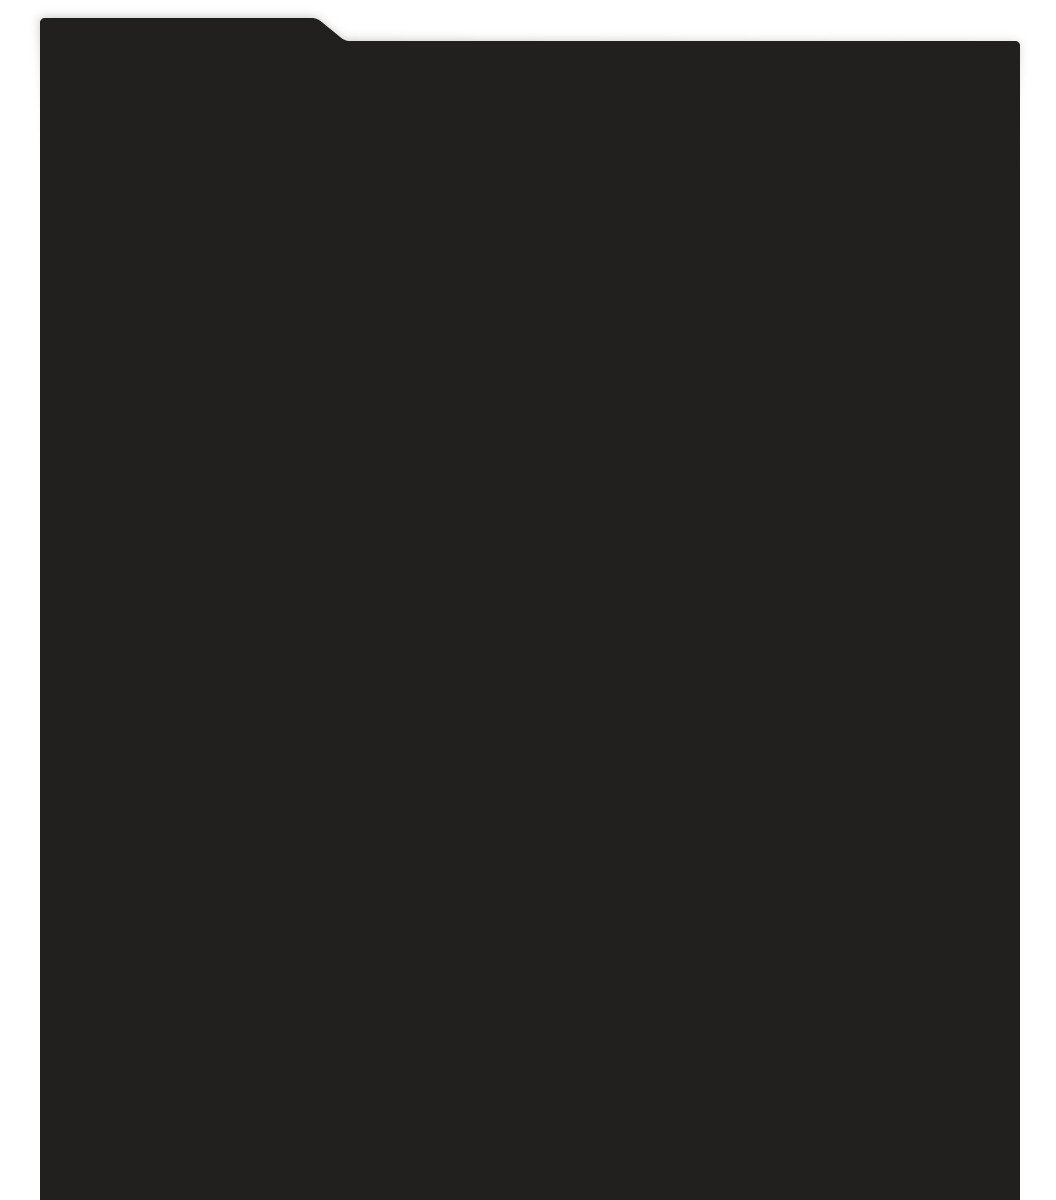
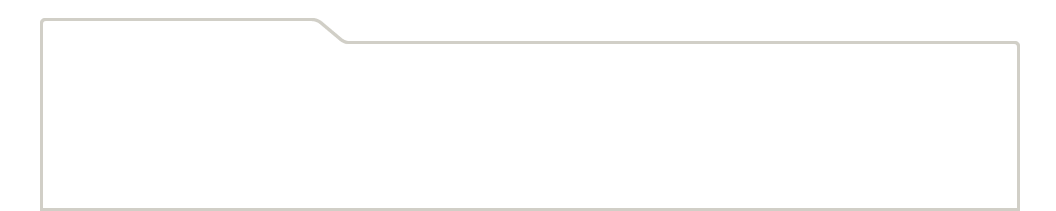
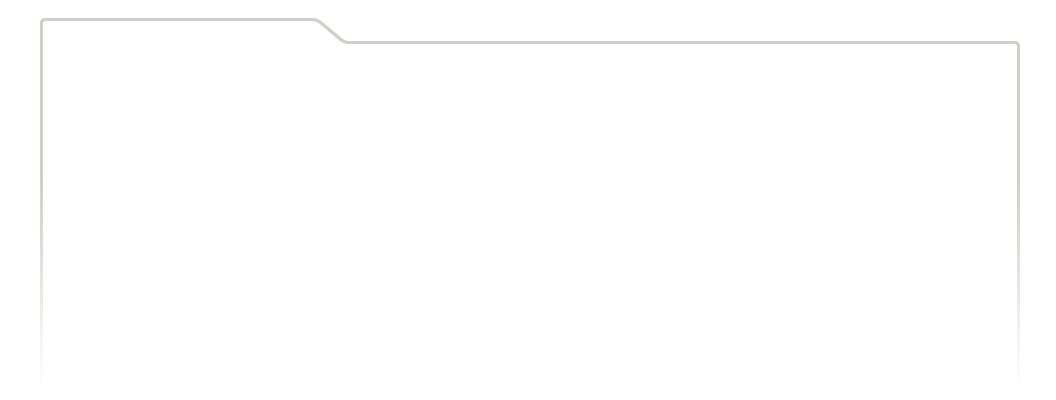
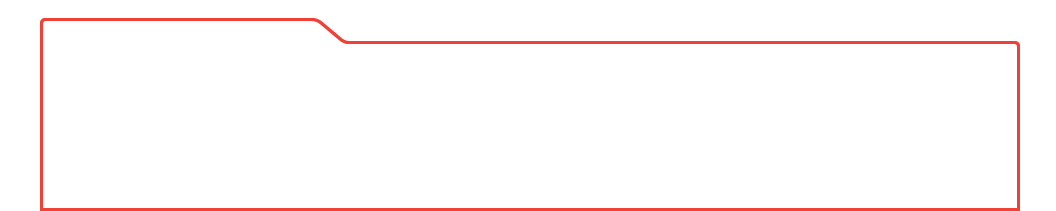
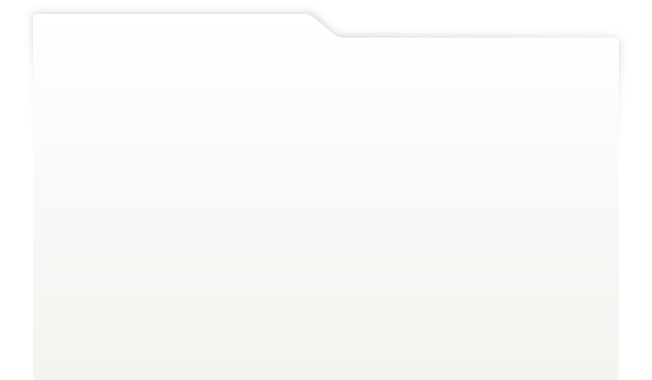
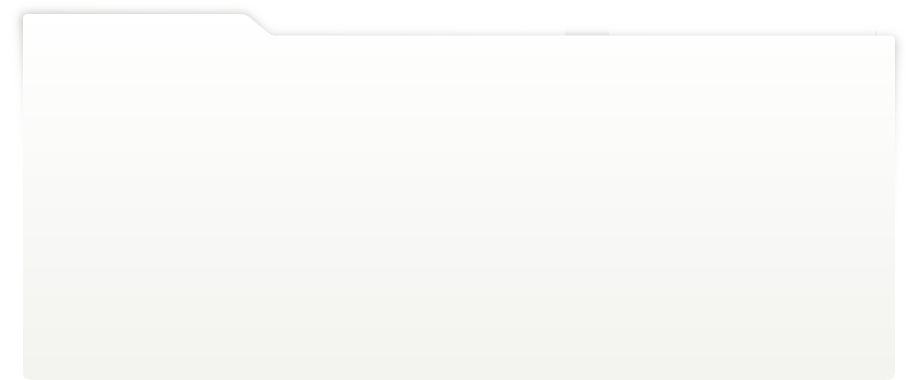
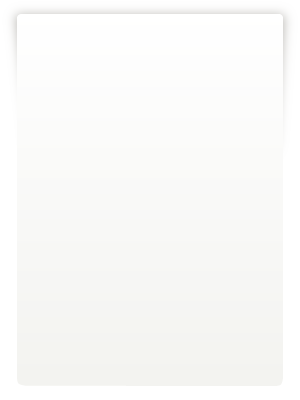
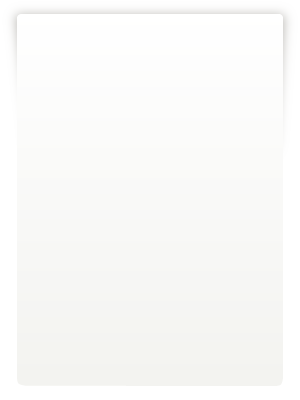
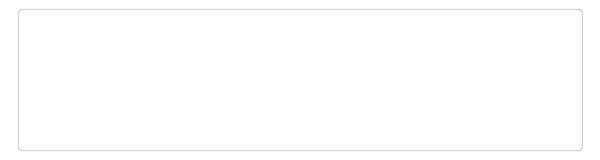
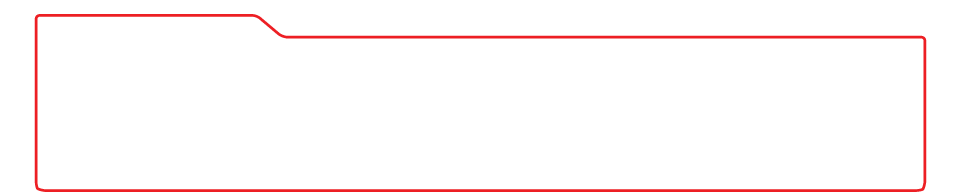
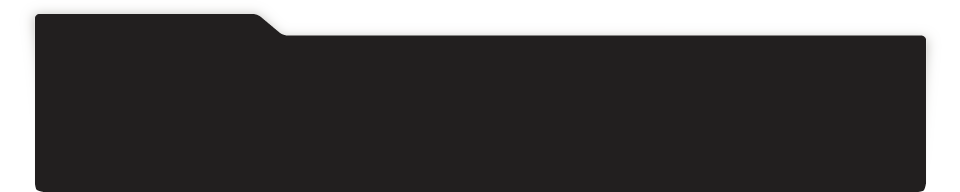
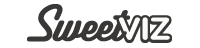
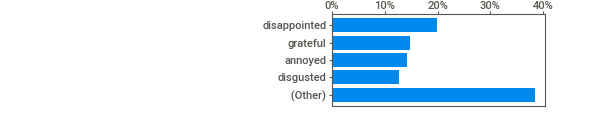
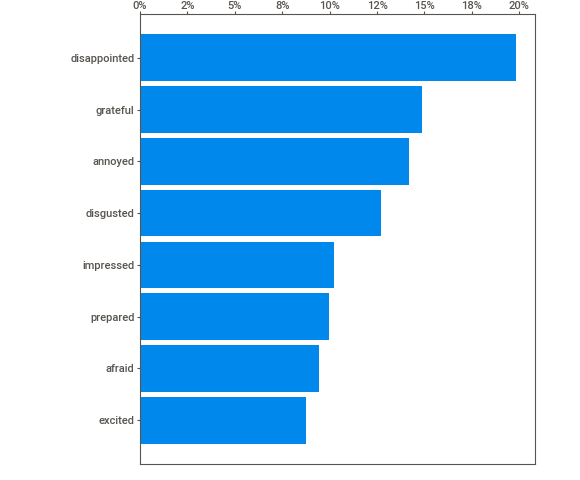
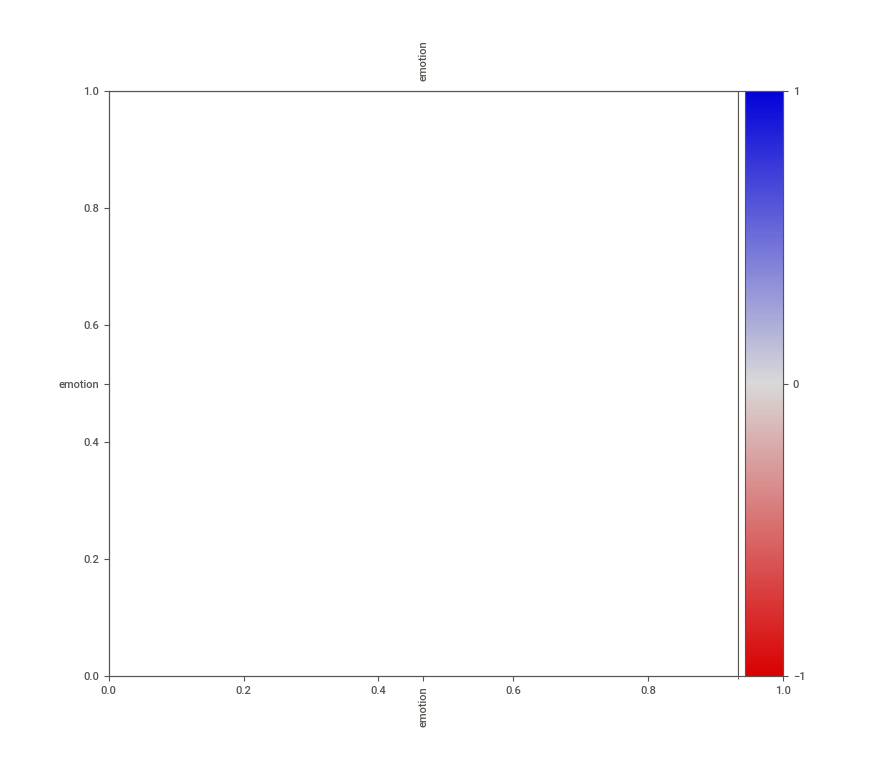
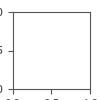

In [16]:
# EDA report 
report = sv.analyze(df)
report.show_notebook()

### Sentence-Level Analysis

#### 1. Sentence Length Analysis

##### a. empathetic_dialogues: desired input

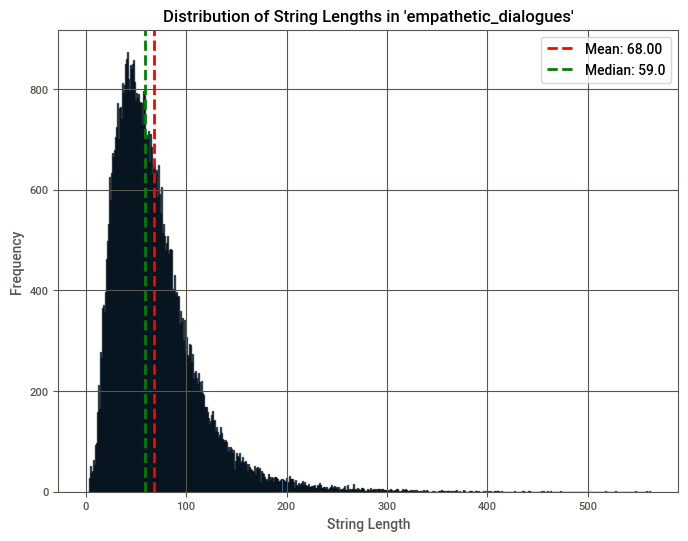

In [94]:
df['len_ed'] = df['empathetic_dialogues'].str.len()

mean_length = df['len_ed'].mean()
median_length = df['len_ed'].median()

plt.figure(figsize=(8, 6))
plt.hist(df['len_ed'], bins=range(1, df['len_ed'].max() + 2), edgecolor='black', alpha=0.7)

plt.axvline(mean_length, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.2f}')
plt.axvline(median_length, color='g', linestyle='dashed', linewidth=2, label=f'Median: {median_length}')

plt.title("Distribution of String Lengths in 'empathetic_dialogues'")
plt.xlabel("String Length")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

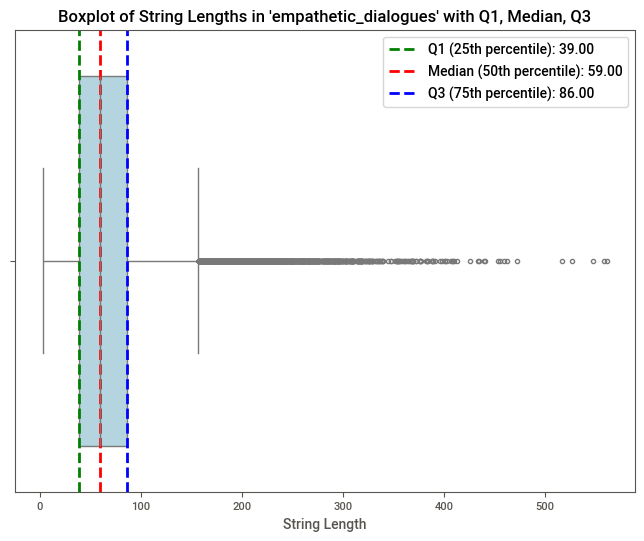

In [95]:
Q1 = df['len_ed'].quantile(0.25)
Q2 = df['len_ed'].quantile(0.50) 
Q3 = df['len_ed'].quantile(0.75)

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['len_ed'], color='lightblue')

plt.axvline(Q1, color='g', linestyle='dashed', linewidth=2, label=f'Q1 (25th percentile): {Q1:.2f}')
plt.axvline(Q2, color='r', linestyle='dashed', linewidth=2, label=f'Median (50th percentile): {Q2:.2f}')
plt.axvline(Q3, color='b', linestyle='dashed', linewidth=2, label=f'Q3 (75th percentile): {Q3:.2f}')

plt.title("Boxplot of String Lengths in 'empathetic_dialogues' with Q1, Median, Q3")
plt.xlabel("String Length")

plt.legend()
plt.show()

In [96]:
closest_examples = df.loc[(df['len_ed'] - mean_length).abs().nsmallest(5).index, 'empathetic_dialogues']

print("Examples of sentences with length close to the mean:")
for sentence in closest_examples:
    print(sentence)

Examples of sentences with length close to the mean:
Got rejected from a place I wanted to work, not once but three times
I just really wanted some ice cream! Now I know their hours, though.
I do sales work, but he always lies to us and takes our bonus money.
Yeah, thank you! at which situation did you feel hope for your life?
I hear ya.. I hope you find one soon... wishing you all of the best!


##### b. labels: desired output

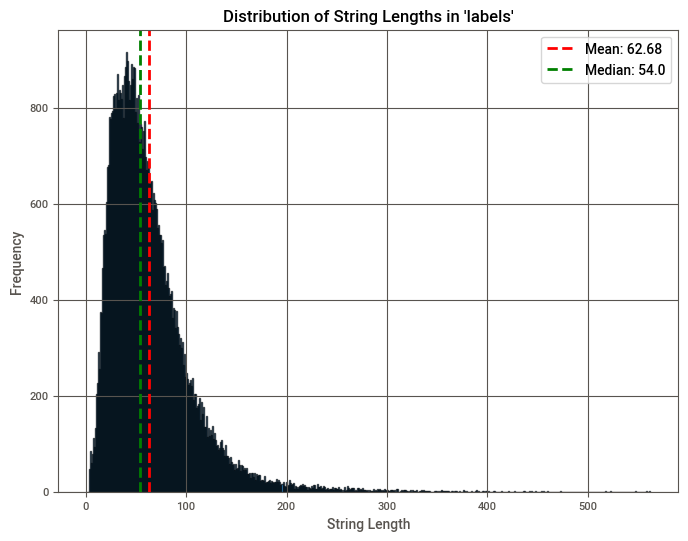

In [97]:
df['len_labels'] = df['labels'].str.len()

mean_length = df['len_labels'].mean()
median_length = df['len_labels'].median()

plt.figure(figsize=(8, 6))
plt.hist(df['len_labels'], bins=range(1, df['len_labels'].max() + 2), edgecolor='black', alpha=0.7)

plt.axvline(mean_length, color='r', linestyle='dashed', linewidth=2, label=f'Mean: {mean_length:.2f}')
plt.axvline(median_length, color='g', linestyle='dashed', linewidth=2, label=f'Median: {median_length}')

plt.title("Distribution of String Lengths in 'labels'")
plt.xlabel("String Length")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

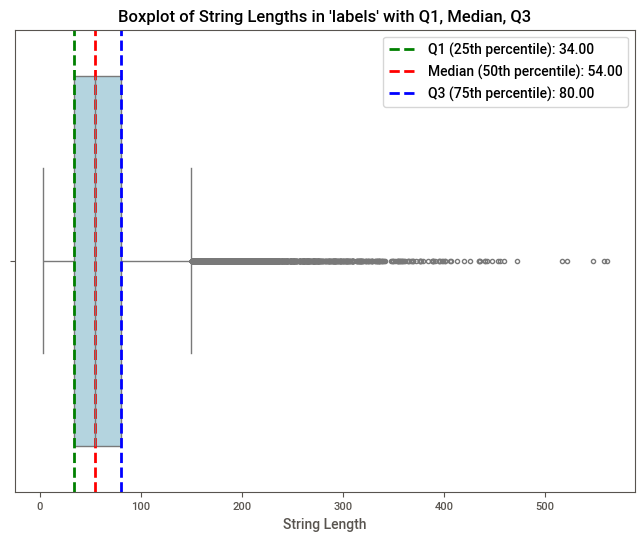

In [98]:
Q1 = df['len_labels'].quantile(0.25)
Q2 = df['len_labels'].quantile(0.50) 
Q3 = df['len_labels'].quantile(0.75)

plt.figure(figsize=(8, 6))
sns.boxplot(x=df['len_labels'], color='lightblue')

plt.axvline(Q1, color='g', linestyle='dashed', linewidth=2, label=f'Q1 (25th percentile): {Q1:.2f}')
plt.axvline(Q2, color='r', linestyle='dashed', linewidth=2, label=f'Median (50th percentile): {Q2:.2f}')
plt.axvline(Q3, color='b', linestyle='dashed', linewidth=2, label=f'Q3 (75th percentile): {Q3:.2f}')

plt.title("Boxplot of String Lengths in 'labels' with Q1, Median, Q3")
plt.xlabel("String Length")

plt.legend()
plt.show()

In [100]:
closest_examples = df.loc[(df['len_labels'] - mean_length).abs().nsmallest(5).index, 'labels']

print("Examples of sentences with length close to the mean:")
for sentence in closest_examples:
    print(sentence)

Examples of sentences with length close to the mean:
Was this a friend you were in love with, or just a best friend?
The grass makes me itchy, But the shower afterward feels great.
I still took it since it was late but I rode in the front seat.
Oh no... were they relaxed about it or did it cause a problem? 
That's really considerate of you. Do they need your help a lot?


In [101]:
df.drop(['len_ed', 'len_labels'], axis=1, inplace=True)

#### 2. Sentence Similarity

**Cosine Similarity**
1. Range and meaning of values
+ 1 (perfectly equal):
  + When two vectors have the same direction.
  + Example: When the meaning or structure of text is nearly identical.
+ 0 (completely independent):
  + When two vectors are orthogonal to each other.
  + Example: When the texts cover completely different topics.
+ -1 (completely opposite):
  + When two vectors are in completely opposite directions.
  + Rarely encountered in textual data, more likely to occur in vectorised data.

In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

In [18]:
def plot_sim(sim_df):
    similarity_values = sim_df.values
    upper_triangle_indices = np.triu_indices_from(similarity_values, k=1)  
    similarity_scores = similarity_values[upper_triangle_indices]

    plt.figure(figsize=(8, 6))
    plt.hist(similarity_scores, bins=30, alpha=0.7, edgecolor='black')
    plt.title("Distribution of Sentence Similarity Scores")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

##### a. empathetic_dialogues: desired input

In [114]:
input_embeddings = model.encode(df['empathetic_dialogues'].tolist())
cosine_sim_matrix = cosine_similarity(input_embeddings)
sim_input = pd.DataFrame(cosine_sim_matrix, columns=df['empathetic_dialogues'], index=df['empathetic_dialogues'])

In [115]:
sim_input

empathetic_dialogues,"I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.",This was a best friend. I miss her.,We no longer talk.,"Was this a friend you were in love with, or just a best friend?",Where has she gone?,it feels like hitting to blank wall when i see the darkness,dont you feel so.. its a wonder,i virtually thought so.. and i used to get sweatings,Oh ya? I don't really see how,I do actually hit blank walls a lot of times but i get by,...,What a scary night that was.,"My house burned night earlier, had to get my mom out.",What happened? Hope you are okay?,I was going through the stuff in my attic last night,Yeah I found some old pictures of when us kids used to go to my grandma's house for xmas,Did you find anything great?,What a wonderful memory.,I woke up this morning to my wife telling me she's pregnant!,"It is soooo awesome. We have been wanting a baby for so long. I can't wait, but I was shocked out of a dead sleep!",Oh hey that's awesome! That is awesome right?
empathetic_dialogues,,,,,,,,,,,,,,,,,,,,,
"I remember going to see the fireworks with my best friend. It was the first time we ever spent time alone together. Although there was a lot of people, we felt like the only people in the world.",1.000000,0.389508,0.210703,0.444943,0.101592,0.113559,0.129068,0.100088,0.050113,0.061007,...,0.299976,0.400496,0.230096,0.257974,0.294999,0.220857,0.296854,0.252652,0.270212,0.253956
This was a best friend. I miss her.,0.389508,1.000000,0.341683,0.586014,0.447045,0.018200,0.142814,0.078520,0.025183,-0.030530,...,0.174216,0.291850,0.291482,0.173304,0.208134,0.144334,0.296060,0.181507,0.087566,0.060532
We no longer talk.,0.210703,0.341683,1.000000,0.178885,0.302556,0.045059,0.102251,0.056538,0.033832,-0.011763,...,0.177352,0.176296,0.339257,0.128248,0.093279,0.021726,0.200269,0.157315,0.068881,-0.014973
"Was this a friend you were in love with, or just a best friend?",0.444943,0.586014,0.178885,1.000000,0.131698,0.008238,0.129547,0.124656,0.081667,-0.068787,...,0.137521,0.219633,0.217241,0.133463,0.055578,0.095120,0.216734,0.173835,0.085065,0.074180
Where has she gone?,0.101592,0.447045,0.302556,0.131698,1.000000,0.049544,0.165009,-0.013740,0.065821,0.003720,...,0.115363,0.234565,0.325990,0.199219,0.182134,0.149353,0.198285,0.183132,0.084329,0.018413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Did you find anything great?,0.220857,0.144334,0.021726,0.095120,0.149353,0.043411,0.105644,0.105672,0.104896,0.156966,...,0.142765,0.136884,0.158119,0.210025,0.349883,1.000000,0.237599,0.112925,0.226264,0.211434
What a wonderful memory.,0.296854,0.296060,0.200269,0.216734,0.198285,0.067666,0.192122,0.092234,0.104102,0.003990,...,0.421682,0.196541,0.128264,0.170319,0.268504,0.237599,1.000000,0.149820,0.154699,0.165352
I woke up this morning to my wife telling me she's pregnant!,0.252652,0.181507,0.157315,0.173835,0.183132,0.153965,0.143621,0.198925,0.032881,0.032345,...,0.319513,0.404509,0.317271,0.344801,0.165672,0.112925,0.149820,1.000000,0.435293,0.165998


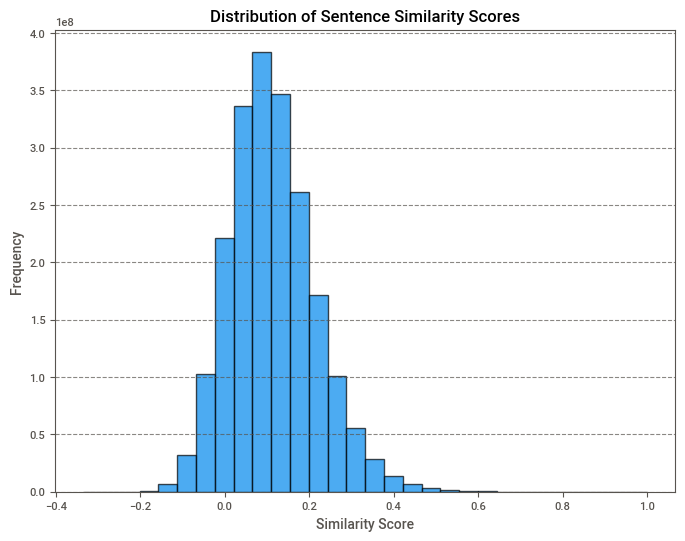

In [116]:
plot_sim(sim_input)

##### b. labels: desired output

In [19]:
label_embeddings = model.encode(df['labels'].tolist())
cosine_sim_matrix = cosine_similarity(label_embeddings)
sim_output_lbl = pd.DataFrame(cosine_sim_matrix, columns=df['labels'], index=df['labels'])

In [118]:
sim_output

labels,"Was this a friend you were in love with, or just a best friend?",Where has she gone?,Oh was this something that happened because of an argument?,This was a best friend. I miss her.,We no longer talk.,Oh ya? I don't really see how,I do actually hit blank walls a lot of times but i get by,Wait what are sweatings,dont you feel so.. its a wonder,i virtually thought so.. and i used to get sweatings,...,What happened? Hope you are okay?,"Omg that is so scary, I am so sorry to hear that.","My house burned night earlier, had to get my mom out.",Did you find anything great?,What a wonderful memory.,Yeah I found some old pictures of when us kids used to go to my grandma's house for xmas,Yeah reminds me of the good old days. I miss my grandma. She passed away about 15 years ago.,Oh hey that's awesome! That is awesome right?,That is awesome!!!! Congratulations!,"It is soooo awesome. We have been wanting a baby for so long. I can't wait, but I was shocked out of a dead sleep!"
labels,,,,,,,,,,,,,,,,,,,,,
"Was this a friend you were in love with, or just a best friend?",1.000000,0.131698,0.122471,0.586014,0.178885,0.081667,-0.068787,-0.020700,0.129547,0.124656,...,0.217241,0.128105,0.219633,0.095120,0.216735,0.055578,0.180464,0.074180,0.101666,0.085065
Where has she gone?,0.131698,1.000000,0.114307,0.447045,0.302556,0.065821,0.003720,0.021023,0.165009,-0.013740,...,0.325990,0.226921,0.234565,0.149353,0.198285,0.182134,0.222379,0.018413,0.075350,0.084329
Oh was this something that happened because of an argument?,0.122471,0.114307,1.000000,0.085261,0.208585,0.087207,0.048898,0.080883,0.170780,0.170093,...,0.293492,0.231990,0.211703,0.110898,0.173325,0.138985,0.087553,0.077073,-0.034500,-0.030110
This was a best friend. I miss her.,0.586014,0.447045,0.085261,1.000000,0.341683,0.025183,-0.030530,-0.003521,0.142814,0.078520,...,0.291482,0.250916,0.291850,0.144334,0.296060,0.208134,0.464150,0.060532,0.116722,0.087566
We no longer talk.,0.178885,0.302556,0.208585,0.341683,1.000000,0.033832,-0.011763,0.061471,0.102251,0.056537,...,0.339257,0.216587,0.176296,0.021726,0.200269,0.093279,0.176761,-0.014973,-0.040513,0.068881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yeah I found some old pictures of when us kids used to go to my grandma's house for xmas,0.055578,0.182134,0.138985,0.208134,0.093279,0.105222,0.118126,0.028652,0.124353,0.125812,...,0.082760,0.245054,0.306668,0.349883,0.268504,1.000000,0.520900,0.232016,0.202859,0.158606
Yeah reminds me of the good old days. I miss my grandma. She passed away about 15 years ago.,0.180464,0.222379,0.087553,0.464150,0.176761,0.074921,0.108817,-0.018970,0.261068,0.109938,...,0.234217,0.381271,0.300904,0.231261,0.361541,0.520900,1.000000,0.137652,0.120598,0.199072
Oh hey that's awesome! That is awesome right?,0.074180,0.018413,0.077073,0.060532,-0.014973,0.265274,0.111088,0.019700,-0.000008,0.128137,...,0.129390,0.204614,0.059701,0.211434,0.165352,0.232016,0.137652,1.000000,0.495040,0.298835


: 

In [22]:
mean_similarity = np.mean(sim_output_lbl.values)
print("Average Cosine Similarity:", mean_similarity)

Average Cosine Similarity: 0.106945805


In [23]:
std_similarity = np.std(sim_output_lbl.values)  # 표준편차
min_similarity = np.min(sim_output_lbl.values)  # 최소값
max_similarity = np.max(sim_output_lbl.values)  # 최대값
median_similarity = np.median(sim_output_lbl.values)  # 중앙값

print(std_similarity,min_similarity,max_similarity,median_similarity)

0.099746935 -0.3501954 1.0000008 0.09882769


In [24]:
sim_values = sim_output_lbl.values.ravel()

In [ ]:
# take so long

# plot_sim(sim_output)
plt.hist(sim_values, bins=50, edgecolor='k', alpha=0.7)
plt.title('Distribution of Cosine Similarity Scores')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

#### 3. Sentiment Analysis

+ -1.0: very negative emotion | e.g. this is terrible
+ 0.0: Neutral emotion | e.g. it's okay
+ 1.0: Very positive emotion | e.g. this is amazing

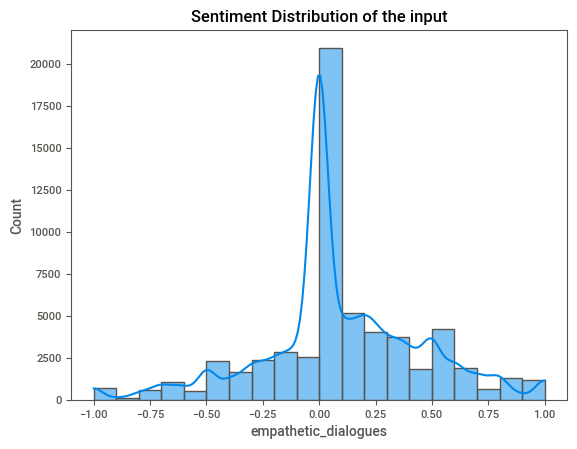

In [19]:
from textblob import TextBlob

input_sentiment = df['empathetic_dialogues'].apply(lambda x: TextBlob(x).sentiment.polarity)
sns.histplot(input_sentiment, kde=True, bins=20)
plt.title('Sentiment Distribution of the input')
plt.show()

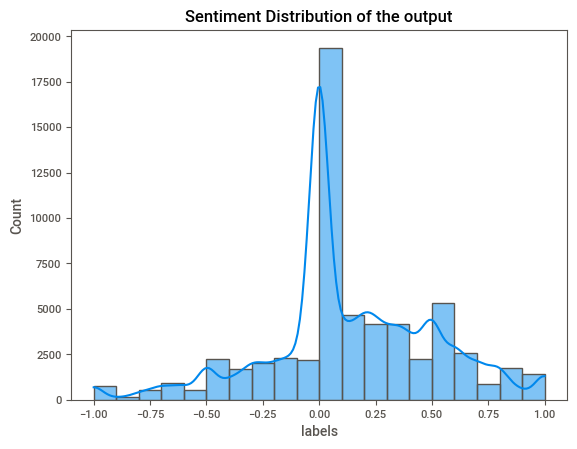

In [20]:
output_sentiment = df['labels'].apply(lambda x: TextBlob(x).sentiment.polarity)
sns.histplot(output_sentiment, kde=True, bins=20)
plt.title('Sentiment Distribution of the output')
plt.show()

### Word-Level Analysis

#### 1. Vocabulary Size

In [105]:
from sklearn.feature_extraction.text import CountVectorizer

##### a. empathetic_dialogues: desired input

Vocab size: 18273


<Figure size 1000x600 with 0 Axes>

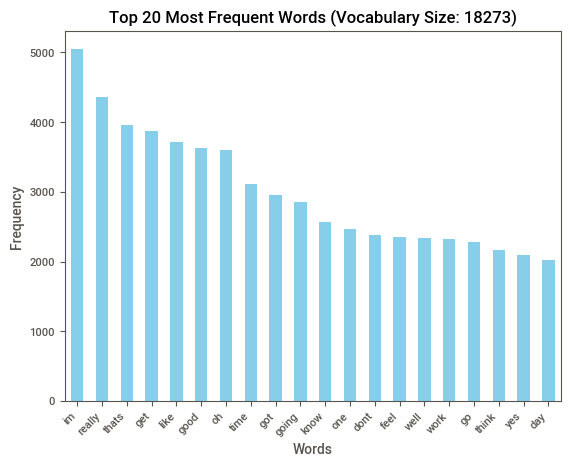

In [112]:
vectorizer = CountVectorizer()
vectorizer.fit(final_df['cleaned_input'])

vocab_size = len(vectorizer.vocabulary_)
print(f"Vocab size: {vocab_size}")

word_freq = vectorizer.transform(final_df['cleaned_input']).sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq_df = pd.DataFrame(list(zip(words, word_freq)), columns=["Word", "Frequency"])
word_freq_df = word_freq_df.sort_values(by="Frequency", ascending=False)

plt.figure(figsize=(10, 6))
word_freq_df.head(20).plot(kind='bar', x='Word', y='Frequency', legend=False, color='skyblue')
plt.title(f"Top 20 Most Frequent Words (Vocabulary Size: {vocab_size})")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.show()

##### b. labels: desired output

Vocab size: 17744


<Figure size 1000x600 with 0 Axes>

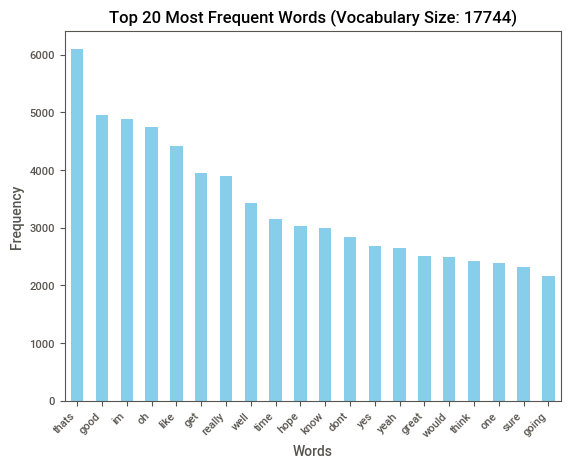

In [113]:
vectorizer = CountVectorizer()
vectorizer.fit(final_df['cleaned_output'])

vocab_size = len(vectorizer.vocabulary_)
print(f"Vocab size: {vocab_size}")

word_freq = vectorizer.transform(final_df['cleaned_output']).sum(axis=0).A1
words = vectorizer.get_feature_names_out()
word_freq_df = pd.DataFrame(list(zip(words, word_freq)), columns=["Word", "Frequency"])
word_freq_df = word_freq_df.sort_values(by="Frequency", ascending=False)

plt.figure(figsize=(10, 6))
word_freq_df.head(20).plot(kind='bar', x='Word', y='Frequency', legend=False, color='skyblue')
plt.title(f"Top 20 Most Frequent Words (Vocabulary Size: {vocab_size})")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha='right')
plt.show()


#### 2. Word Cloud

In [17]:
from wordcloud import WordCloud

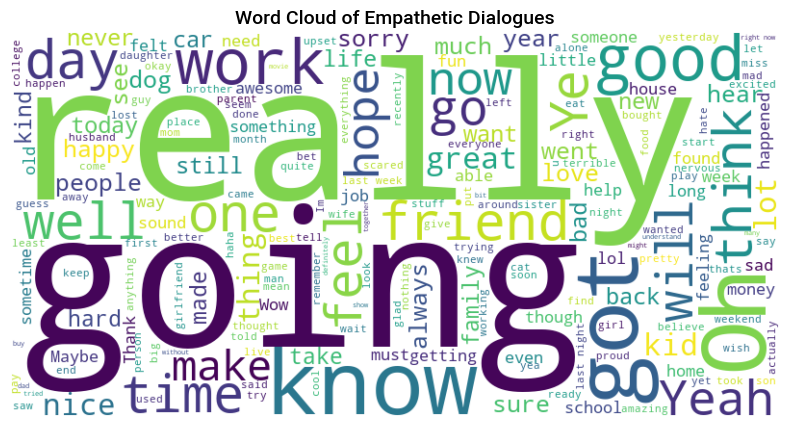

In [18]:
text_data = " ".join(df['empathetic_dialogues'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(text_data)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Empathetic Dialogues", fontsize=14)
plt.show()

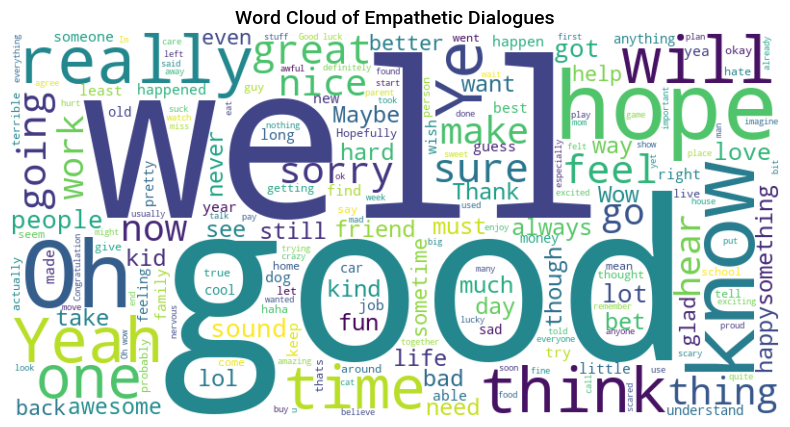

In [20]:
text_data = " ".join(df['labels'].dropna())

wordcloud = WordCloud(width=800, height=400, background_color="white", colormap="viridis").generate(text_data)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Empathetic Dialogues", fontsize=14)
plt.show()

#### 3. Latent Dirichlet Allocation (LDA)

In [21]:
from gensim import corpora
from gensim.models.ldamodel import LdaModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

In [22]:
question = final_df['cleaned_input'].astype(str)
answer = final_df['cleaned_output'].astype(str)

In [23]:
processed_q = question.apply(preprocess)
processed_a = answer.apply(preprocess)

In [24]:
dictionary_q = corpora.Dictionary(processed_q)
dictionary_a = corpora.Dictionary(processed_a)

corpus_q = [dictionary_q.doc2bow(doc) for doc in processed_q]
corpus_a = [dictionary_a.doc2bow(doc) for doc in processed_a]

In [26]:
lda_model_q = LdaModel(corpus=corpus_q, id2word=dictionary_q, num_topics=5, passes=10, random_state=42)

for idx, topic in lda_model_q.print_topics(-1):
    print(f"Topic {idx}: {topic}")

lda_model_a = LdaModel(corpus=corpus_a, id2word=dictionary_a, num_topics=5, passes=10, random_state=42)

for idx, topic in lda_model_a.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.054*"thats" + 0.054*"oh" + 0.034*"good" + 0.030*"great" + 0.023*"nice" + 0.020*"really" + 0.017*"wow" + 0.017*"hope" + 0.016*"long" + 0.016*"sounds"
Topic 1: 0.021*"bad" + 0.015*"dog" + 0.014*"someone" + 0.010*"got" + 0.010*"feel" + 0.009*"felt" + 0.009*"car" + 0.009*"day" + 0.008*"friend" + 0.008*"told"
Topic 2: 0.025*"got" + 0.019*"last" + 0.017*"went" + 0.015*"work" + 0.015*"get" + 0.014*"week" + 0.014*"first" + 0.014*"new" + 0.012*"time" + 0.012*"school"
Topic 3: 0.034*"like" + 0.022*"know" + 0.019*"think" + 0.019*"dont" + 0.014*"feel" + 0.014*"get" + 0.013*"really" + 0.013*"would" + 0.013*"people" + 0.012*"good"
Topic 4: 0.061*"im" + 0.017*"old" + 0.017*"sorry" + 0.015*"years" + 0.014*"hear" + 0.014*"sure" + 0.010*"right" + 0.009*"ive" + 0.009*"ago" + 0.008*"days"
Topic 0: 0.020*"im" + 0.019*"going" + 0.017*"one" + 0.015*"got" + 0.013*"day" + 0.013*"get" + 0.012*"time" + 0.011*"years" + 0.011*"back" + 0.009*"yes"
Topic 1: 0.061*"like" + 0.020*"love" + 0.020*"good" + 0.0

**0. How can we interpret them?**
+ Topics don’t necessarily represent fixed categories but rather recurring patterns in the dataset.
  
**1. Input topics**
+ Topic 0
  + Top words: "im", "get", "work", "going", "job", "school".
  + Possible Theme: Daily routines, career, and education. 
  + This topic might reflect conversations about work, school, or personal plans.
+ Topic 1
  + Top words: "last", "got", "car", "friend", "year", "night".
  + Possible Theme: Social events and past experiences. 
  + The emphasis on "last", "got", "friend", and "year" suggests discussions about recent events, memories, or interactions with others.
+ Topic 2
  + Top words: "good", "life", "love", "feel", "kid".
  + Possible Theme: Emotional well-being and relationships. 
  + This topic may capture reflections on personal feelings, relationships (like "love" and "life"), and family (e.g., "kid").
+ Topic 3
  + Top words: "know", "dont", "like", "really", "dog", "today".
  + Possible Theme: General conversations or opinions. 
  + The presence of "know", "dont", and "like" suggests casual exchanges or personal commentary, potentially including pets or daily happenings ("dog", "today").
+ Topic 4
  + Top words: "old", "cant", "away", "found", "back", "believe".
  + Possible Theme: Reflections and transitions. 
  + This topic might involve discussions about change, age, or experiences from the past (e.g., "old", "ago", "back").

**2. Output topics**
+ Topic 0
  + Top words: "thats", "good", "oh", "must", "going", "great", "awesome", "happened", "wow", "feel".
  + Theme: Expressions of excitement or surprise.
    + The frequent use of words like "thats", "oh", "must", and "wow" suggests reactions to surprising or impressive events.
  + Positive descriptors like "good", "great", and "awesome" indicate a celebratory or affirming tone.
+ Topic 1
  + Top words: "think", "dont", "would", "something", "know", "like", "could", "way", "feel", "ive".
  + Theme: Contemplation or speculation.
    + This topic captures reflective or uncertain statements, as seen with "think", "dont", "would", and "could".
    + The presence of "feel" and "something" suggests introspection or abstract discussions.
+ Topic 2
  + Top words: "like", "nice", "sounds", "get", "time", "thats", "good", "go", "fun", "long".
  + Theme: Plans and enjoyment.
    + The words "nice", "sounds", "time", and "fun" indicate casual conversations about activities or experiences.
    + "Get", "go", and "long" suggest some focus on movement or time duration.
+ Topic 3
  + Top words: "oh", "im", "sorry", "hear", "sure", "hope", "glad", "really", "thing", "sad".
  + Theme: Sympathy or consolation.
    + The dominance of "oh" and "sorry" indicates empathetic responses.
    + Words like "hear", "sad", and "hope" reinforce a theme of concern or offering comfort.
+ Topic 4
  + Top words: "thats", "cool", "love", "pretty", "yes", "sweet", "haha", "lucky", "really", "kind".
  + Theme: Lighthearted admiration or positivity.
    + Words like "cool", "love", "sweet", and "haha" suggest a fun, easygoing tone.
    + "Lucky" and "pretty" hint at admiration or appreciation for situations or people.


**What is the λ?**

+ λ = 1.0: Topic-centric interpretation
  + When you want to find topic-specific words: Set lambda close to 1.0 to see the most unique words in each topic.
+ λ = 0.0: dataset-wide frequency-centred interpretation
  + When you want to see the impact of common words: Setting lambda close to 0.0 reveals the most frequent words in the dataset overall. This gives you a sense of the overall nature of your data.
+ λ = 0.5 (intermediate value): Balanced interpretation of topic and overall frequency



In [32]:
lda_vis_q = gensimvis.prepare(lda_model_q, corpus_q, dictionary_q)
pyLDAvis.display(lda_vis_q)

In [33]:
lda_vis_a = gensimvis.prepare(lda_model_a, corpus_a, dictionary_a)
pyLDAvis.display(lda_vis_a)

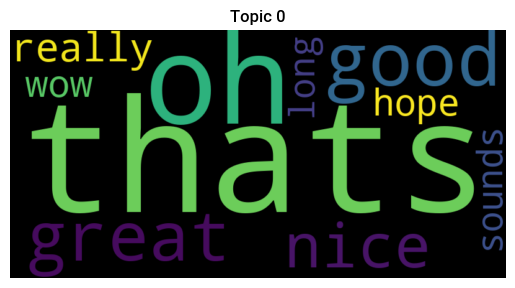

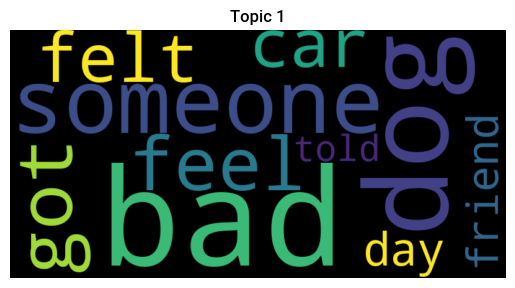

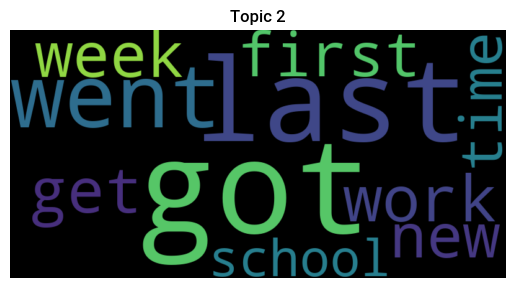

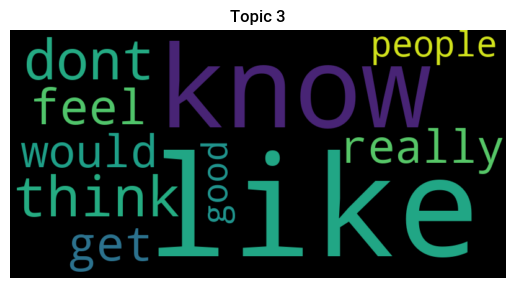

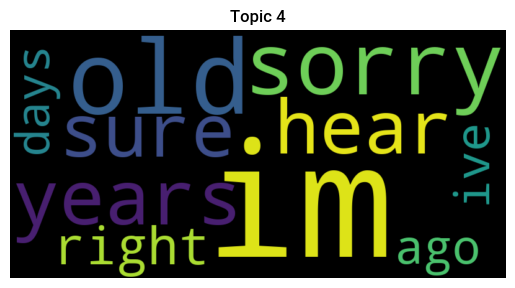

In [27]:
from wordcloud import WordCloud

for idx, topic in lda_model_q.show_topics(num_topics=5, formatted=False):
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(topic))
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(f'Topic {idx}')
    plt.show()

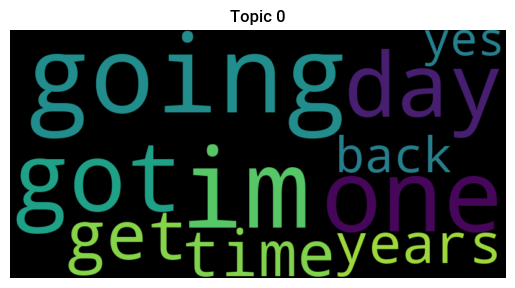

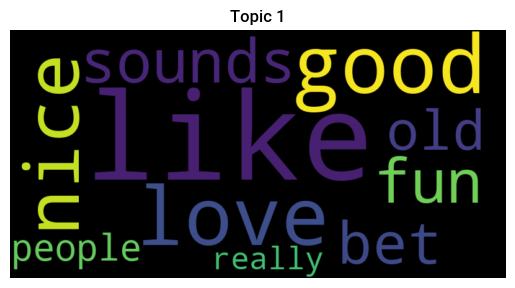

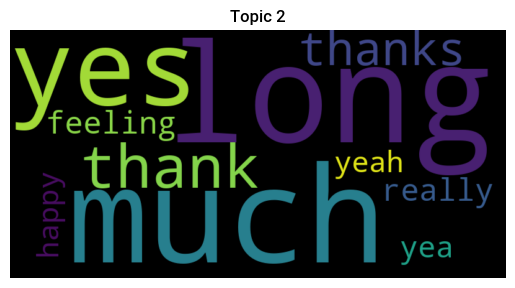

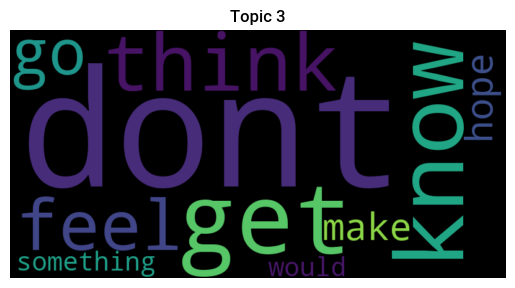

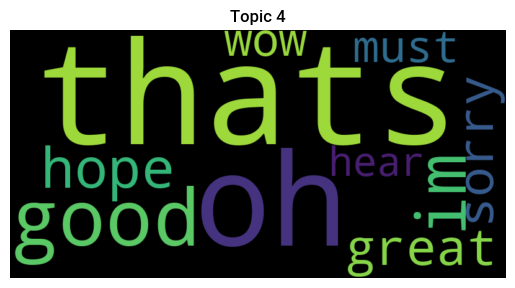

In [28]:
for idx, topic in lda_model_a.show_topics(num_topics=5, formatted=False):
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(topic))
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(f'Topic {idx}')
    plt.show()

topic 3

In [29]:
lda_model_q = LdaModel(corpus=corpus_q, id2word=dictionary_q, num_topics=3, passes=10, random_state=42)

for idx, topic in lda_model_q.print_topics(-1):
    print(f"Topic {idx}: {topic}")

lda_model_a = LdaModel(corpus=corpus_a, id2word=dictionary_a, num_topics=3, passes=10, random_state=42)

for idx, topic in lda_model_a.print_topics(-1):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.038*"im" + 0.030*"good" + 0.028*"thats" + 0.028*"oh" + 0.019*"really" + 0.017*"well" + 0.015*"great" + 0.015*"yeah" + 0.014*"hope" + 0.013*"sure"
Topic 1: 0.017*"feel" + 0.017*"know" + 0.016*"like" + 0.015*"dont" + 0.012*"would" + 0.011*"bad" + 0.011*"people" + 0.010*"old" + 0.009*"love" + 0.009*"really"
Topic 2: 0.019*"got" + 0.012*"new" + 0.011*"last" + 0.011*"work" + 0.011*"friend" + 0.010*"going" + 0.010*"day" + 0.010*"went" + 0.009*"home" + 0.008*"years"
Topic 0: 0.032*"im" + 0.018*"get" + 0.016*"know" + 0.016*"dont" + 0.016*"think" + 0.015*"sure" + 0.013*"go" + 0.013*"sorry" + 0.011*"time" + 0.010*"work"
Topic 1: 0.048*"thats" + 0.043*"good" + 0.037*"like" + 0.022*"great" + 0.016*"nice" + 0.015*"sounds" + 0.013*"really" + 0.012*"love" + 0.010*"always" + 0.010*"oh"
Topic 2: 0.019*"feel" + 0.018*"oh" + 0.017*"really" + 0.014*"wow" + 0.014*"much" + 0.013*"must" + 0.012*"bad" + 0.011*"yes" + 0.011*"hope" + 0.010*"long"


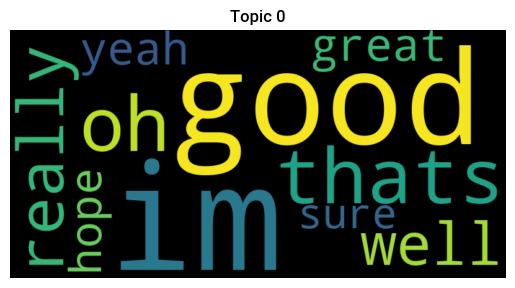

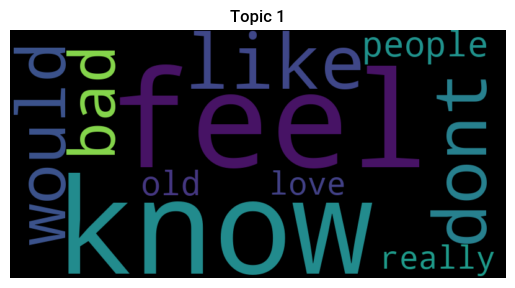

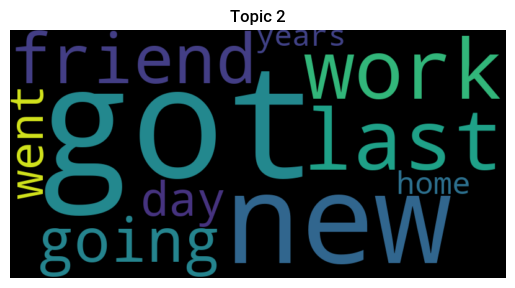

In [30]:
from wordcloud import WordCloud

for idx, topic in lda_model_q.show_topics(num_topics=3, formatted=False):
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(topic))
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(f'Topic {idx}')
    plt.show()

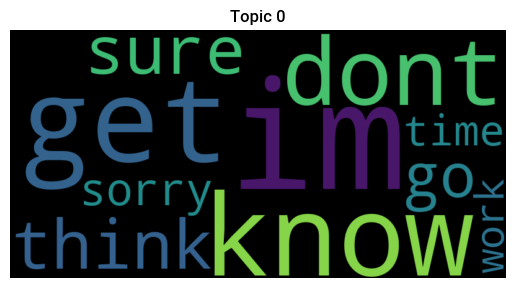

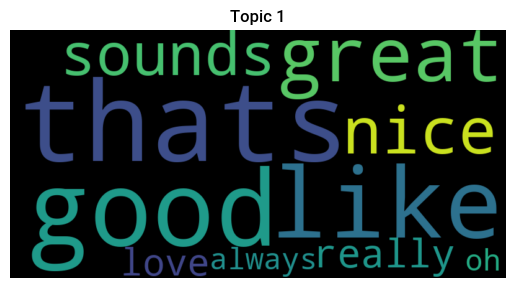

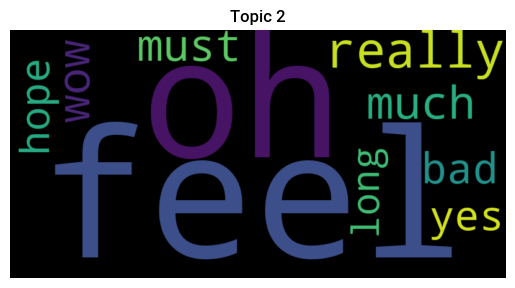

In [31]:
from wordcloud import WordCloud

for idx, topic in lda_model_a.show_topics(num_topics=3, formatted=False):
    wordcloud = WordCloud(width=800, height=400).generate_from_frequencies(dict(topic))
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(f'Topic {idx}')
    plt.show()

## Save txt file

In [ ]:
def save_conversation_to_file(df, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            f.write(f"<bot> {row['empathetic_dialogues']} <endOfText>\n")
            f.write(f"<human> {row['labels']} <endOfText>\n")

output_file = '../../data/emotion.txt'
save_conversation_to_file(final_df, output_file)

In [ ]:
# Stop word removed version: we didn't use it for training!

def save_conversation_to_file(df, file_path):
    with open(file_path, 'w', encoding='utf-8') as f:
        for _, row in df.iterrows():
            f.write(f"<bot> {row['cleaned_input']} <endOfText>\n")
            f.write(f"<human> {row['cleaned_output']} <endOfText>\n")

output_file = '../../data/emotion_cleaned.txt'
save_conversation_to_file(final_df, output_file)

## _Additional Experiment_
+ Please ignore :)

+ Adding dramatic conversation
1. Sad

In [58]:
from transformers import pipeline
import random

generator = pipeline("text-generation", model="EleutherAI/gpt-neo-2.7B")

sad_situations = [
    "I failed at the test today",
    "I lost my job recently",
    "My pet passed away",
    "I had a fight with my best friend",
    "I feel like nobody understands me",
    "My vacation plans got canceled",
    "I am struggling with my health",
    "I feel very lonely today",
    "I missed an important opportunity",
    "I am feeling overwhelmed by work",
    "I made a big mistake at my job",
    "I feel like I am not good enough",
    "I lost someone I cared about deeply",
    "I didn’t achieve my goals this year",
    "I feel like giving up on my dreams",
    "I am feeling unappreciated at home",
    "My relationship is not going well",
    "I lost a competition I worked hard for",
    "My financial situation is very stressful",
    "I feel stuck in life",
    "I feel so lonely these days.",
    "I lost my pet yesterday.",
    "I failed my job interview today.",
    "I just can't seem to do anything right.",
    "My best friend is moving away.",
    "I got rejected by the person I like.",
    "My parents don't understand me.",
    "I feel like nobody cares about me.",
    "I missed an important opportunity today.",
    "I had a fight with someone I care about.",
    "I feel like I'm stuck in life.",
    "I can't seem to find a way out of my problems.",
    "I feel like a failure.",
    "I got bad news from the doctor.",
    "My plans completely fell apart today.",
    "I feel like I'm always disappointing people.",
    "My loved one is sick and suffering.",
    "I'm overwhelmed with everything going on in my life.",
    "I feel so left out all the time.",
    "I can't stop thinking about my mistakes."
]

def generate_comforting_pairs(situations, num_samples=100):
    data_pairs = []
    for _ in range(num_samples):
        situation = random.choice(situations)
        prompt = f"I am so sad today because {situation}. What would you say to comfort me?"
        response = generator(prompt, max_length=50, num_return_sequences=1)[0]['generated_text']
        
        comforting_message = response.replace(prompt, "").strip()
        
        data_pairs.append({
            "sad_situation": f"I am so sad today because {situation}",
            "comforting_message": comforting_message
        })
    
    return data_pairs

data_pairs = generate_comforting_pairs(sad_situations, num_samples=100)

for i, pair in enumerate(data_pairs[:10]):  
    print(f"Pair {i+1}")
    print(f"Sad Situation: {pair['sad_situation']}")
    print(f"Comforting Message: {pair['comforting_message']}")
    print()

# # CSV로 저장 (선택 사항)
# import pandas as pd
# df = pd.DataFrame(data_pairs)
# df.to_csv("comforting_data_pairs.csv", index=False)

# print("100 data pairs saved to 'comforting_data_pairs.csv'.")


Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.


KeyboardInterrupt: 

In [52]:
import pandas as pd

# Generate examples of sad conversation pairs
inputs = [
    "I feel so lonely these days.",
    "I lost my pet yesterday.",
    "I failed my job interview today.",
    "I just can't seem to do anything right.",
    "My best friend is moving away.",
    "I got rejected by the person I like.",
    "My parents don't understand me.",
    "I feel like nobody cares about me.",
    "I missed an important opportunity today.",
    "I had a fight with someone I care about.",
    "I feel like I'm stuck in life.",
    "I can't seem to find a way out of my problems.",
    "I feel like a failure.",
    "I got bad news from the doctor.",
    "My plans completely fell apart today.",
    "I feel like I'm always disappointing people.",
    "My loved one is sick and suffering.",
    "I'm overwhelmed with everything going on in my life.",
    "I feel so left out all the time.",
    "I can't stop thinking about my mistakes."
]

outputs = [
    "I'm so sorry to hear that. You're not alone, and things will get better soon.",
    "I'm deeply sorry for your loss. Remember the joy they brought into your life.",
    "That must be so disappointing. Keep trying; something better is out there for you.",
    "I'm so sorry you're feeling this way. You're more capable than you know.",
    "That must be so hard. I'm here for you if you need someone to talk to.",
    "I'm so sorry to hear that. Remember, the right person will come into your life.",
    "That must feel so frustrating. Communication is hard, but things can improve.",
    "I'm sorry you're feeling this way. You matter so much more than you know.",
    "I'm sorry to hear that. There will be other opportunities, so don't give up hope.",
    "That sounds so painful. I hope you can find a way to make amends and heal.",
    "It's okay to feel stuck sometimes. Things will start moving forward again soon.",
    "That sounds overwhelming. You're stronger than you think, and you can get through this.",
    "I'm so sorry you're feeling like this. Everyone fails sometimes, but it doesn't define you.",
    "I'm sorry to hear that. Take it one step at a time, and seek support if you can.",
    "That must feel devastating. It's okay to take time to grieve and regroup.",
    "It sounds like you're being really hard on yourself. Nobody's perfect, and you're doing your best.",
    "I'm so sorry to hear that. You and your loved one are in my thoughts.",
    "That sounds like so much to handle. Try to take it one step at a time.",
    "I'm sorry you're feeling left out. Your presence matters so much to those who care about you.",
    "Mistakes are hard to live with, but they don't define who you are."
]


In [53]:
# Expand to 10,000 examples by duplicating and varying phrasing
data = []
for i in range(500):  # Increase the loop to create more examples
    for input_text, output_text in zip(inputs, outputs):
        data.append((input_text, output_text))

# Convert to DataFrame
df_10k = pd.DataFrame(data[:10000], columns=["Input", "Output"])  # Ensure exactly 10,000 rows
df_10k.head()

,Input,Output
0,I feel so lonely these days.,"I'm so sorry to hear that. You're not alone, and things will get better soon."
1,I lost my pet yesterday.,I'm deeply sorry for your loss. Remember the joy they brought into your life.
2,I failed my job interview today.,That must be so disappointing. Keep trying; something better is out there for you.
3,I just can't seem to do anything right.,I'm so sorry you're feeling this way. You're more capable than you know.
4,My best friend is moving away.,That must be so hard. I'm here for you if you need someone to talk to.


In [57]:
df_10k.head(40)


,Input,Output
0,I feel so lonely these days.,"I'm so sorry to hear that. You're not alone, and things will get better soon."
1,I lost my pet yesterday.,I'm deeply sorry for your loss. Remember the joy they brought into your life.
2,I failed my job interview today.,That must be so disappointing. Keep trying; something better is out there for you.
3,I just can't seem to do anything right.,I'm so sorry you're feeling this way. You're more capable than you know.
4,My best friend is moving away.,That must be so hard. I'm here for you if you need someone to talk to.
5,I got rejected by the person I like.,"I'm so sorry to hear that. Remember, the right person will come into your life."
6,My parents don't understand me.,"That must feel so frustrating. Communication is hard, but things can improve."
7,I feel like nobody cares about me.,I'm sorry you're feeling this way. You matter so much more than you know.
8,I missed an important opportunity today.,"I'm sorry to hear that. There will be other opportunities, so don't give up hope."
9,I had a fight with someone I care about.,That sounds so painful. I hope you can find a way to make amends and heal.


In [ ]:
from itertools import product

# Expanded input examples with variations
expanded_inputs = [
    "I feel so lonely these days.",
    "I’ve been feeling really lonely lately.",
    "These days, I feel incredibly isolated.",
    "I lost my pet yesterday.",
    "My pet passed away, and I miss them so much.",
    "I failed my job interview today.",
    "I couldn’t get the job I wanted.",
    "I just can't seem to do anything right.",
    "I feel like everything I do ends in failure.",
    "My best friend is moving away.",
    "I got rejected by the person I like.",
    "The person I love doesn’t feel the same way about me.",
    "My parents don't understand me.",
    "I feel like my parents don’t care about my feelings.",
    "I feel like nobody cares about me.",
    "I missed an important opportunity today.",
    "I couldn’t seize a chance that meant so much to me.",
    "I had a fight with someone I care about.",
    "I argued with a loved one, and now I feel awful.",
    "I feel like I'm stuck in life.",
    "I feel like there’s no progress in my life.",
    "I can't seem to find a way out of my problems.",
    "I feel trapped by my circumstances.",
    "I feel like a failure.",
    "I keep disappointing myself with my mistakes.",
    "I got bad news from the doctor.",
    "I’m scared about what the doctor told me.",
    "My plans completely fell apart today.",
    "Everything I worked for crumbled today.",
    "I feel like I'm always disappointing people.",
    "I’m scared I’ll never live up to expectations.",
    "My loved one is sick and suffering.",
    "It hurts so much to see my loved one in pain.",
    "I'm overwhelmed with everything going on in my life.",
    "I feel so stressed and don’t know what to do.",
    "I feel so left out all the time.",
    "I feel like I’m invisible to everyone around me.",
    "I can't stop thinking about my mistakes.",
    "My past mistakes keep haunting me."
]

expanded_outputs = [
    "I'm so sorry to hear that. You're not alone, and things will get better soon.",
    "That must be so hard. I'm here for you if you need someone to talk to.",
    "I can't imagine how tough that must be for you. You're stronger than you know.",
    "I'm deeply sorry for your loss. Remember the joy they brought into your life.",
    "That sounds so painful. It's okay to feel this way, and things will improve with time.",
    "That must feel so frustrating. Keep trying; something better is out there for you.",
    "I'm so sorry you're feeling like this. Everyone struggles sometimes, and it's okay.",
    "It must feel overwhelming right now, but take it one step at a time. You're capable.",
    "I'm sorry to hear that. There will be other opportunities, so don't give up hope.",
    "That sounds heartbreaking. I hope you can find comfort and peace soon.",
    "It's okay to feel stuck sometimes. Things will start moving forward again soon.",
    "That must feel devastating. Remember, you're not defined by your setbacks.",
    "It's tough to face disappointment. I'm here if you need support.",
    "I'm sorry to hear that. Take it one step at a time, and seek support if you can.",
    "That must feel overwhelming. You're stronger than you think, and you can get through this.",
    "It's so hard to see a loved one in pain. You and your loved one are in my thoughts.",
    "That sounds like so much to handle. Try to take it one step at a time.",
    "I'm sorry you're feeling left out. Your presence matters so much to those who care about you.",
    "Mistakes are hard to live with, but they don't define who you are.",
    "That must feel so isolating. You're not alone, even if it feels that way."
]

# Create all possible pairs up to 10,000 examples
conversation_pairs = list(product(expanded_inputs, expanded_outputs))[:10000]

# Convert to DataFrame
df_large = pd.DataFrame(conversation_pairs, columns=["Input", "Output"])

# Save to CSV
file_path_large = "/mnt/data/sad_conversation_data_10k_expanded.csv"
df_large.to_csv(file_path_large, index=False)

file_path_large


+ Adding normal dialogue
1. DailyDialog: A Manually Labelled Multi-turn Dialogue Dataset
   + Data does not exist in pairs, but is continuous
   + http://yanran.li/dailydialog 

In [80]:
file_path = '../../data/dialogues_text.txt'

with open(file_path, 'r', encoding='utf-8') as f:
    dialogues = f.readlines()

data = ''.join(dialogues)
utterances = data.split(' __eou__')

dialogue_pairs = []

for i in range(0, len(utterances)-1, 2):
    if i + 1 < len(utterances): 
        dialogue_pairs.append([utterances[i].strip(), utterances[i + 1].strip()])

new_df = pd.DataFrame(dialogue_pairs, columns=['input', 'output'])
new_df.tail(50)

,input,output
51440,"Yes , furthering my education is already bringing about positive results in my workplace as it has boosted my confidence.As well the tutoring system my school employs offers courses uniquely suite",Really ? That's great that you found a school that puts your need first .
51441,As well my company has been very supportive about my decision.They ' Ve cut back my working hours in order to accommodate my studies .,That's great . They must really be committed to staff development .
51442,They are.We definitely see eye-to eye on my enhanced performance being a win-win situation for everyone involved .,"Can you tell me , Ms . Smith , about the training programs you initiated this year ?"
51443,We ran a call center training service and language program to ensure that our customer service representatives are well trained .,What ’ s the result ?
51444,We directly attribute an increase in our customer service feedback of 50 % to the increase in language skills and training that our employees have received .,That seems very impressive . Good work !
51445,"Thank you , but I cannot take all the credit . Our employees have all worked very hard to increase their productivity level .",I ’ d like to open a current account .
51446,Certainly . May I see your social security and your ID Please .,Here your are . I wonder how much interest can I earn for my current account .
51447,Oh . Current account don ’ t pay our interest .,Why is that ?
51448,"It ’ s primarily design for business transactions . That is write checks to pay the bills , buying things and sending money . We won ’ t expect a large amount of deposit in current account .",I see . How do I draw money from my news then .
51449,"Well , we've finally put the finishing touches on the training programs for next year . Here's a report showing the projected costs as well as the expected return on investment .",Return on investment ? How can you have a return on this kind of investment ? Can you really calculate the value of these training programs ?


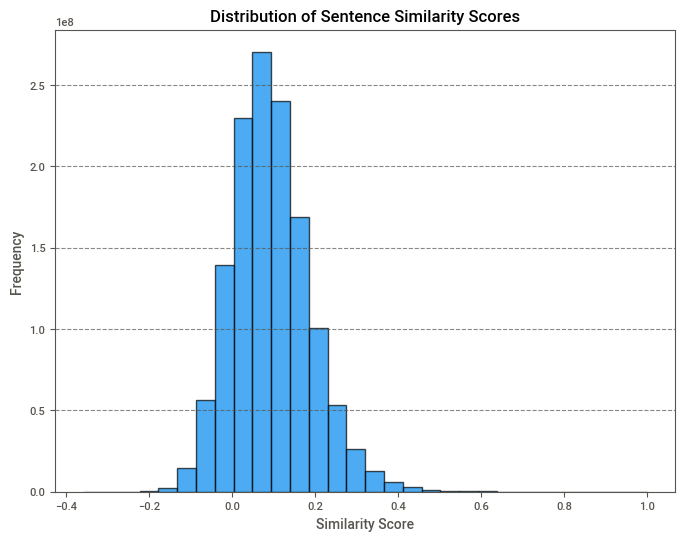

In [81]:
model = SentenceTransformer('all-MiniLM-L6-v2')
label_embeddings = model.encode(new_df['input'].tolist())
cosine_sim_matrix = cosine_similarity(label_embeddings)
similarity_df = pd.DataFrame(cosine_sim_matrix, columns=new_df['input'], index=new_df['input'])

similarity_values = similarity_df.values
upper_triangle_indices = np.triu_indices_from(similarity_values, k=1)  
similarity_scores = similarity_values[upper_triangle_indices]

plt.figure(figsize=(8, 6))
plt.hist(similarity_scores, bins=30, alpha=0.7, edgecolor='black')
plt.title("Distribution of Sentence Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [1]:
model = SentenceTransformer('all-MiniLM-L6-v2')
label_embeddings = model.encode(new_df['output'].tolist())
cosine_sim_matrix = cosine_similarity(label_embeddings)
similarity_df = pd.DataFrame(cosine_sim_matrix, columns=new_df['output'], index=new_df['output'])

similarity_values = similarity_df.values
upper_triangle_indices = np.triu_indices_from(similarity_values, k=1)  
similarity_scores = similarity_values[upper_triangle_indices]

plt.figure(figsize=(8, 6))
plt.hist(similarity_scores, bins=30, alpha=0.7, edgecolor='black')
plt.title("Distribution of Sentence Similarity Scores")
plt.xlabel("Similarity Score")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

NameError: name 'SentenceTransformer' is not defined